In [84]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
#import pandas as pd

Co57_Ge_spec = np.load("data/Co57-Ge Spectrum/spectrum_height.npy")
Co57_NaI_spec = np.load("data/Co57-NaI Spectrum/spectrum_height.npy")
Co60_Ge_spec = np.load("data/Co60-Ge Spectrum/spectrum_height.npy")
Co60_NaI_spec = np.load("data/Co60-NaI Spectrum/spectrum_height.npy")

Cs137_Ge_spec = np.load("data/Cs137-Ge Spectrum/spectrum_height.npy")
Cs137_NaI_spec = np.load("data/Cs137-NaI Spectrum/spectrum_height.npy")

Na_22_co = np.genfromtxt("data/Na22 Coincidence/coincidences.csv", skip_header=True, delimiter=",")[:,3:5]
Na22_Ge_spec = np.load("data/Na22-Ge Spectrum/spectrum_height.npy")
Na22_NaI_spec = np.load("data/Na22-NaI Spectrum/spectrum_height.npy")

spectras_Ge = [Na22_Ge_spec,Na22_Ge_spec, Cs137_Ge_spec, Co57_Ge_spec]
spectras_NaI = [Na22_NaI_spec, Na22_NaI_spec,Cs137_NaI_spec, Co57_NaI_spec]
probes = ["Na22","Na22", "Cs137", "Co57"]

(4095,)


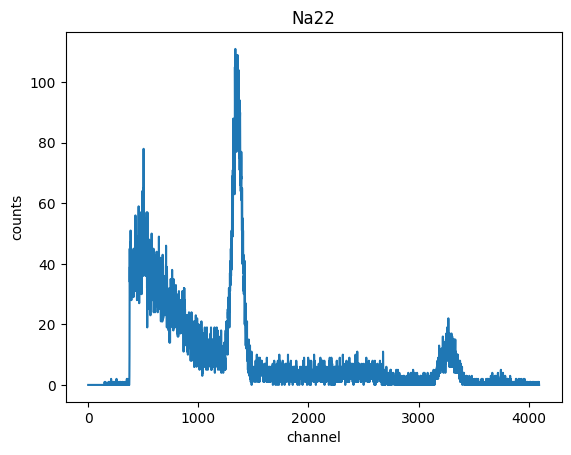

(4095,)


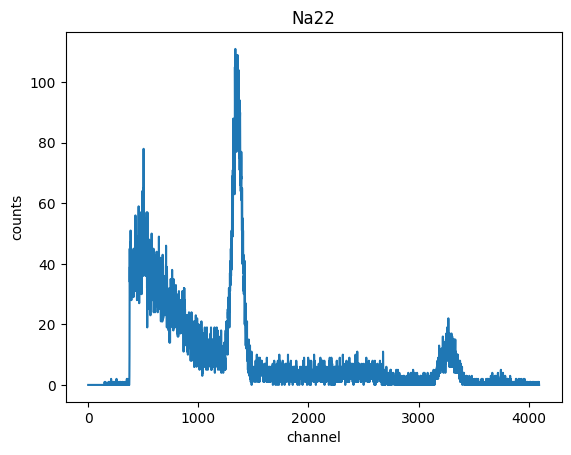

(4095,)


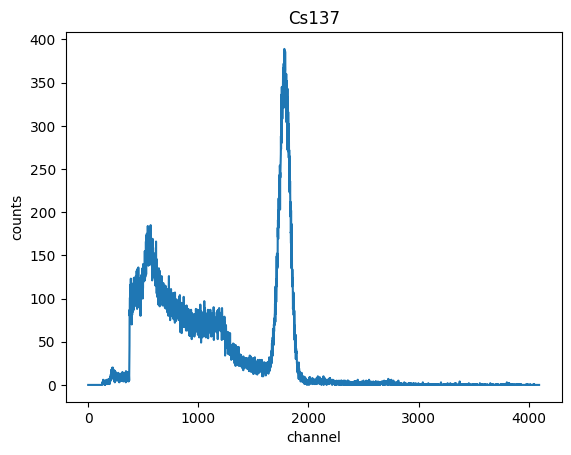

(4095,)


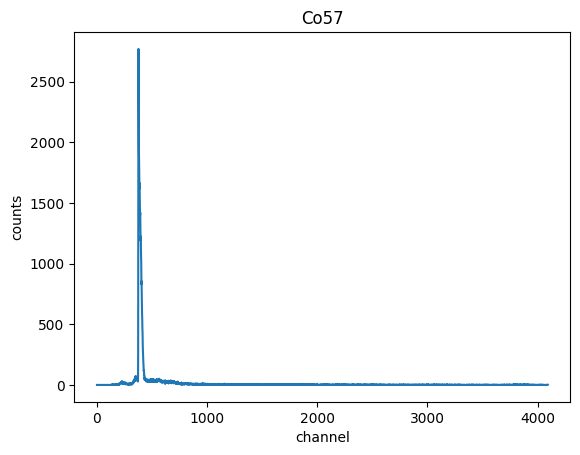

In [93]:
for i, spec in enumerate(spectras_NaI):
    print(spec.shape)
    plt.plot(np.arange(len(spec)), spec)
    plt.title(probes[i])
    plt.xlabel("channel")
    plt.ylabel("counts")
    plt.show()

(6039, 2)


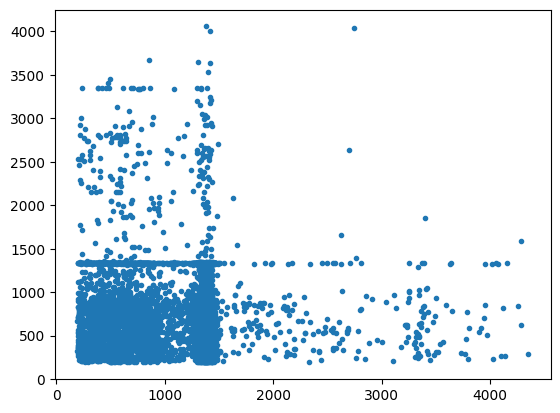

In [86]:
print(Na_22_co.shape)
plt.scatter(Na_22_co[:,0], Na_22_co[:,1], marker=".")

(4095,)


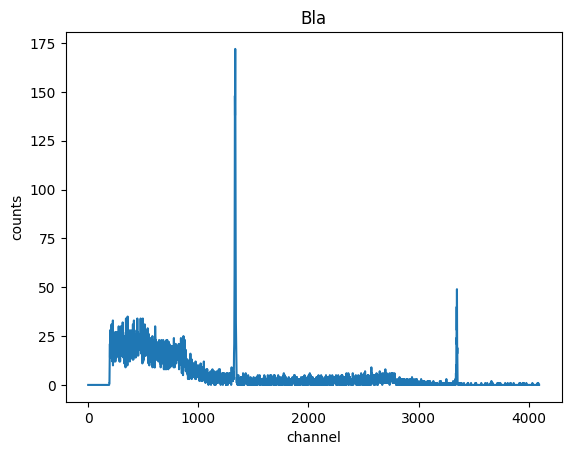

In [87]:
    print(spec.shape)
    plt.plot(np.arange(len(spectras_Ge[0])), spectras_Ge[0])
    plt.title('Bla')
    plt.xlabel("channel")
    plt.ylabel("counts")
    plt.show()

## Energiekalibration Ge-Detektor

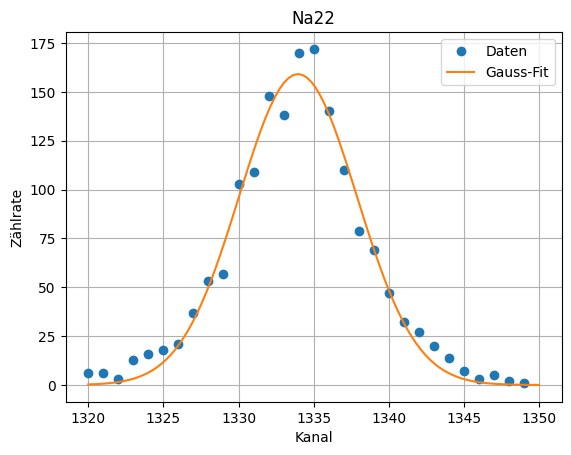

Amplitude: 159.13, Mittelwert: 1333.96, Sigma: 3.92


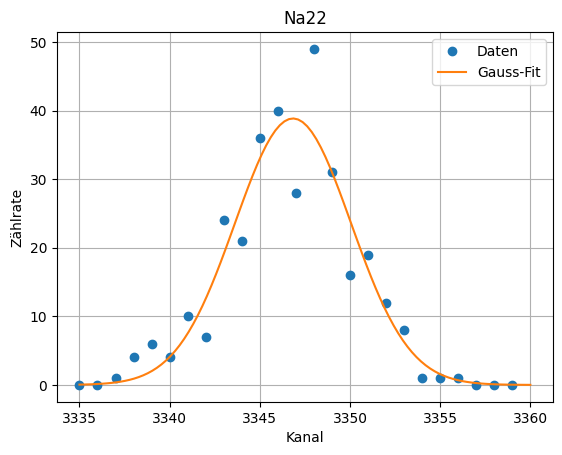

Amplitude: 38.86, Mittelwert: 3346.84, Sigma: 3.22


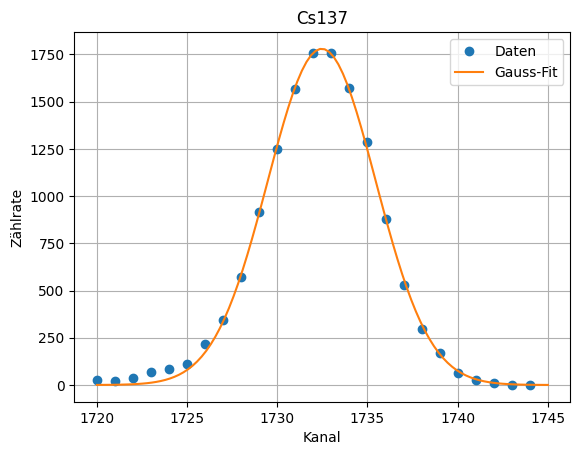

Amplitude: 1779.71, Mittelwert: 1732.46, Sigma: 2.99


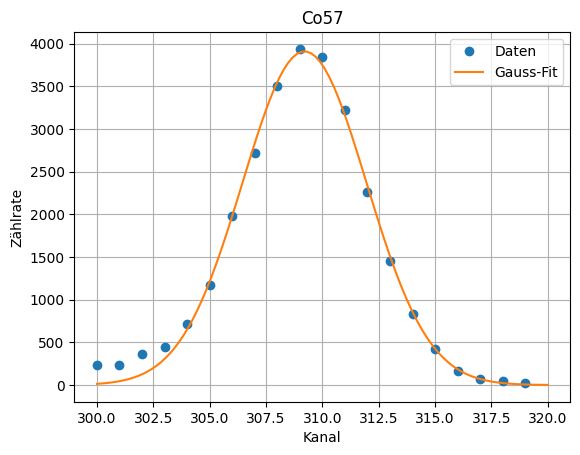

Amplitude: 3907.93, Mittelwert: 309.21, Sigma: 2.75


In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
area = np.array([[1320,1350], [3335,3360], [1720,1745], [300,320]])



def Gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
mu_arr = np.array([])
for i, spec in enumerate(spectras_Ge):

    xdata = np.arange(len(spec))[area[i,0]:area[i,1]]
    ydata = spec[area[i,0]:area[i,1]] 
    
    p0 = [np.max(ydata), xdata[np.argmax(ydata)], 2]


    parameters, _ = curve_fit(Gauss, xdata, ydata, p0=p0)


    A_fit, mu_fit, sigma_fit = parameters
    fit_y = Gauss(np.linspace(area[i,0], area[i,1], 100), A_fit, mu_fit, sigma_fit)
    mu_arr = np.append(mu_arr, mu_fit)


    plt.plot(xdata, ydata, 'o', label='Daten')
    plt.plot(np.linspace(area[i,0], area[i,1],100), fit_y, '-', label='Gauss-Fit')
    plt.legend()
    plt.xlabel("Kanal")
    plt.ylabel("Zählrate")
    plt.title(probes[i])
    plt.grid(True)
    plt.show()

    print(f"Amplitude: {A_fit:.2f}, Mittelwert: {mu_fit:.2f}, Sigma: {sigma_fit:.2f}")


[1351.89335776 3271.51878714 1783.05401885  378.31477621]


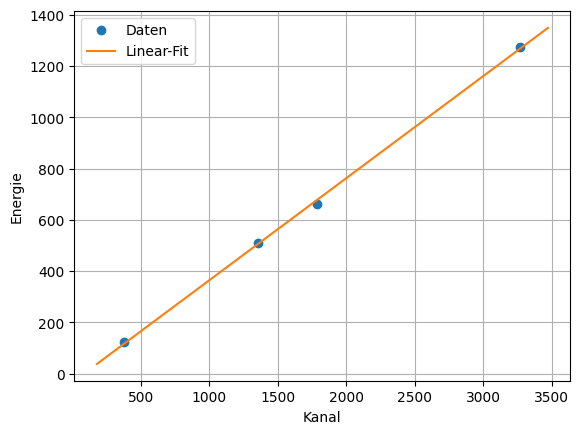

Steigung: 0.40, y-Aschsenabschnitt: -32.66


In [122]:
print(mu_arr)
def Linear(x, m,c):
    return m*x +c 
Elit = [511,1275, 662, 122]

parameters, _ = curve_fit(Linear, mu_arr, Elit)

mg, cg = parameters
fit_y = Linear(np.linspace(np.min(mu_arr)-200, np.max(mu_arr)+200, 1000), mg, cg)

plt.plot(mu_arr, Elit, 'o', label='Daten')
plt.plot(np.linspace(np.min(mu_arr)-200, np.max(mu_arr)+200, 1000), fit_y, '-', label='Linear-Fit')
plt.legend()
plt.xlabel("Kanal")
plt.ylabel("Energie")
plt.grid(True)
plt.show()

print(f"Steigung: {mg:.2f}, y-Aschsenabschnitt: {cg:.2f}")


## Energiekalibration NaJ-Detektor

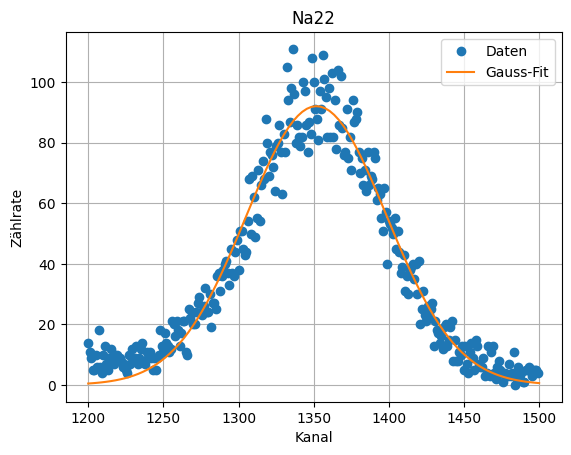

Amplitude: 92.09, Mittelwert: 1351.89, Sigma: 46.69


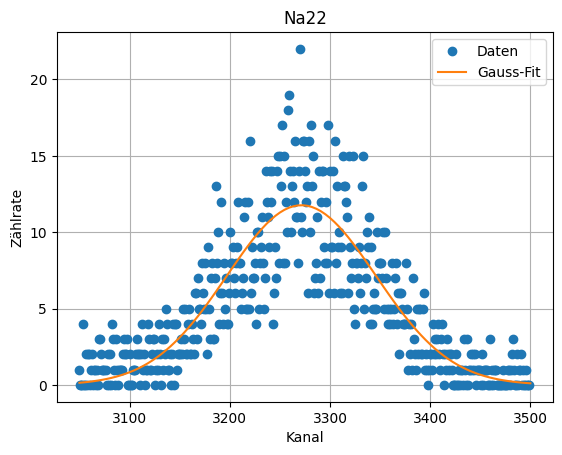

Amplitude: 11.77, Mittelwert: 3271.52, Sigma: 74.48


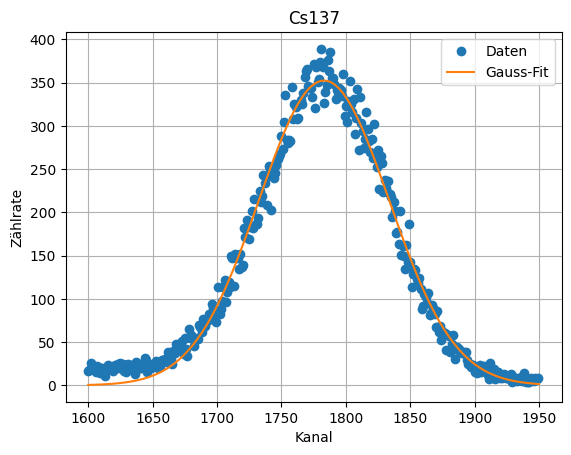

Amplitude: 352.49, Mittelwert: 1783.05, Sigma: 50.62


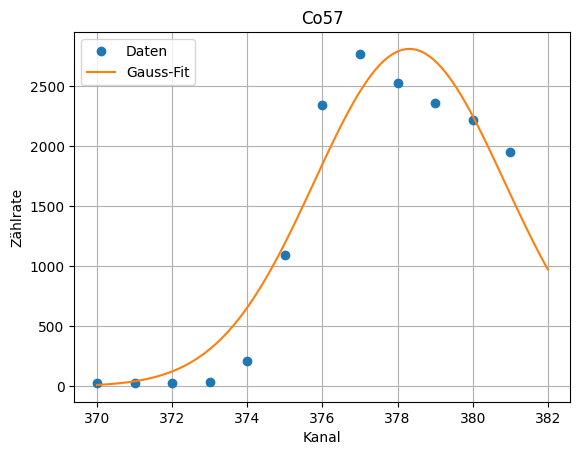

Amplitude: 2809.85, Mittelwert: 378.31, Sigma: 2.53


In [123]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
area = np.array([[1200,1500], [3050,3500], [1600,1950], [370,382]])



def Gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
mu_arr = np.array([])
for i, spec in enumerate(spectras_NaI):

    xdata = np.arange(len(spec))[area[i,0]:area[i,1]]
    ydata = spec[area[i,0]:area[i,1]] 
    
    p0 = [np.max(ydata), xdata[np.argmax(ydata)], 2]


    parameters, _ = curve_fit(Gauss, xdata, ydata, p0=p0)


    A_fit, mu_fit, sigma_fit = parameters
    fit_y = Gauss(np.linspace(area[i,0], area[i,1], 100), A_fit, mu_fit, sigma_fit)
    mu_arr = np.append(mu_arr, mu_fit)


    plt.plot(xdata, ydata, 'o', label='Daten')
    plt.plot(np.linspace(area[i,0], area[i,1],100), fit_y, '-', label='Gauss-Fit')
    plt.legend()
    plt.xlabel("Kanal")
    plt.ylabel("Zählrate")
    plt.title(probes[i])
    plt.grid(True)
    plt.show()

    print(f"Amplitude: {A_fit:.2f}, Mittelwert: {mu_fit:.2f}, Sigma: {sigma_fit:.2f}")


[1351.89335776 3271.51878714 1783.05401885  378.31477621]


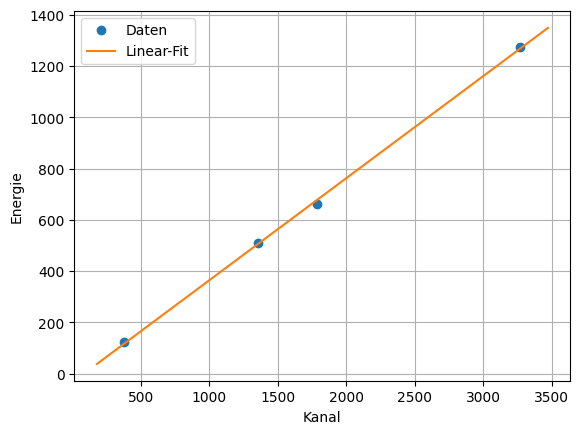

Steigung: 0.40, y-Aschsenabschnitt: -32.66


In [124]:
print(mu_arr)
def Linear(x, m,c):
    return m*x +c 
Elit = [511,1275, 662, 122]

parameters, _ = curve_fit(Linear, mu_arr, Elit)

mn, cn = parameters
fit_y = Linear(np.linspace(np.min(mu_arr)-200, np.max(mu_arr)+200, 1000), mn, cn)

plt.plot(mu_arr, Elit, 'o', label='Daten')
plt.plot(np.linspace(np.min(mu_arr)-200, np.max(mu_arr)+200, 1000), fit_y, '-', label='Linear-Fit')
plt.legend()
plt.xlabel("Kanal")
plt.ylabel("Energie")
plt.grid(True)
plt.show()

print(f"Steigung: {mn:.2f}, y-Aschsenabschnitt: {cn:.2f}")


## Co60 Spektrum

### Darstellung über Kanäle

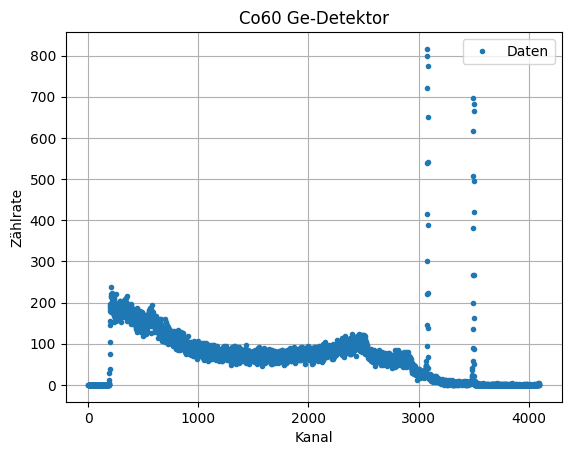

In [121]:
xdata = np.arange(len(Co60_Ge_spec))
ydata = Co60_Ge_spec 

plt.plot(xdata, ydata, '.', label='Daten')
plt.legend()
plt.xlabel("Kanal")
plt.ylabel("Zählrate")
plt.title('Co60 Ge-Detektor')
plt.grid(True)
plt.show()


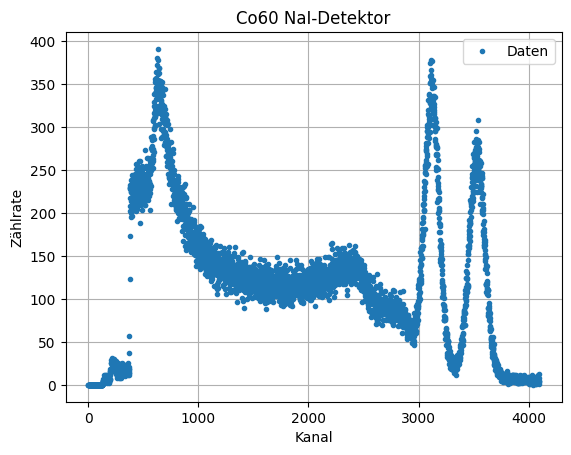

In [120]:
xdata = np.arange(len(Co60_NaI_spec))
ydata = Co60_NaI_spec 

plt.plot(xdata, ydata, '.', label='Daten')
plt.legend()
plt.xlabel("Kanal")
plt.ylabel("Zählrate")
plt.title('Co60 NaI-Detektor')
plt.grid(True)
plt.show()

### Darstellung über Energie

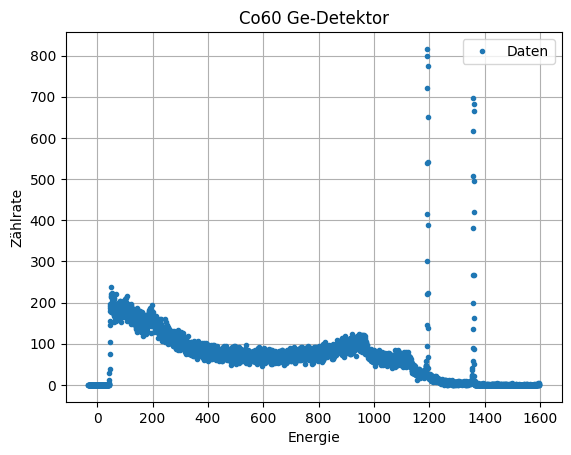

In [129]:
xdata = Linear(np.arange(len(Co60_Ge_spec)), mg  , cg  )
ydata = Co60_Ge_spec 

plt.plot(xdata, ydata, '.', label='Daten')
plt.legend()
plt.xlabel("Energie")
plt.ylabel("Zählrate")
plt.title('Co60 Ge-Detektor')
plt.grid(True)
plt.show()

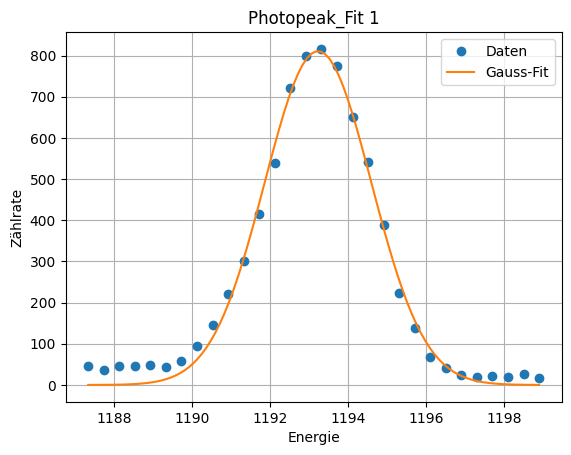

Amplitude: 810.59, Mittelwert: 1193.23, Sigma: 1.37


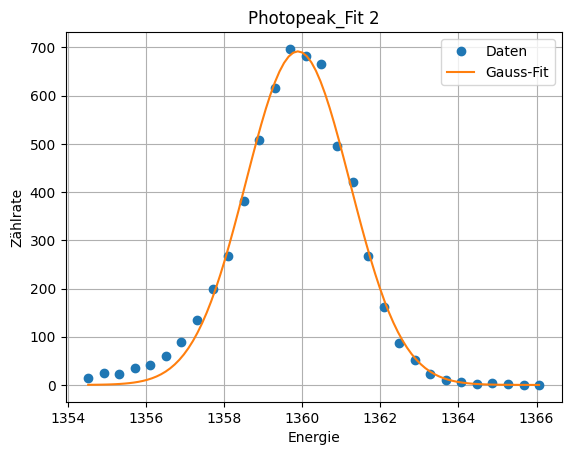

Amplitude: 691.96, Mittelwert: 1359.89, Sigma: 1.33


In [166]:
area = np.array([[3065,3095], [3485,3515]])



def Gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
mu_arr = np.array([])

for i in range(len(area)):

    xdata = Linear(np.arange(len(Co60_Ge_spec)), mg  , cg  )[area[i,0]:area[i,1]]
    ydata = Co60_Ge_spec[area[i,0]:area[i,1]] 
    
    p0 = [np.max(ydata), xdata[np.argmax(ydata)], 2]


    parameters, _ = curve_fit(Gauss, xdata, ydata, p0=p0)


    A_fit, mu_fit, sigma_fit = parameters
    fit_y = Gauss(np.linspace(xdata[0], xdata[-1], 100), A_fit, mu_fit, sigma_fit)
    mu_arr = np.append(mu_arr, mu_fit)


    plt.plot(xdata, ydata, 'o', label='Daten')
    plt.plot(np.linspace(xdata[0], xdata[-1],100), fit_y, '-', label='Gauss-Fit')
    plt.legend()
    plt.xlabel("Energie")
    plt.ylabel("Zählrate")
    plt.title(f'Photopeak_Fit {i+1}')
    plt.grid(True)
    plt.show()
    print(f"Amplitude: {A_fit:.2f}, Mittelwert: {mu_fit:.2f}, Sigma: {sigma_fit:.2f}")


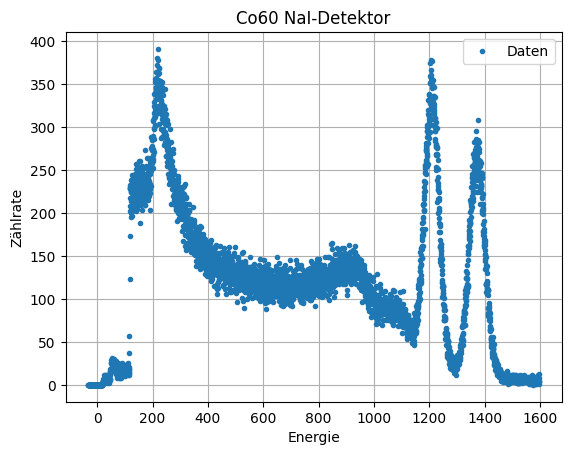

In [128]:
xdata = Linear(np.arange(len(Co60_NaI_spec)), mn  , cn  )
ydata = Co60_NaI_spec 

plt.plot(xdata, ydata, '.', label='Daten')
plt.legend()
plt.xlabel("Energie")
plt.ylabel("Zählrate")
plt.title('Co60 NaI-Detektor')
plt.grid(True)
plt.show()

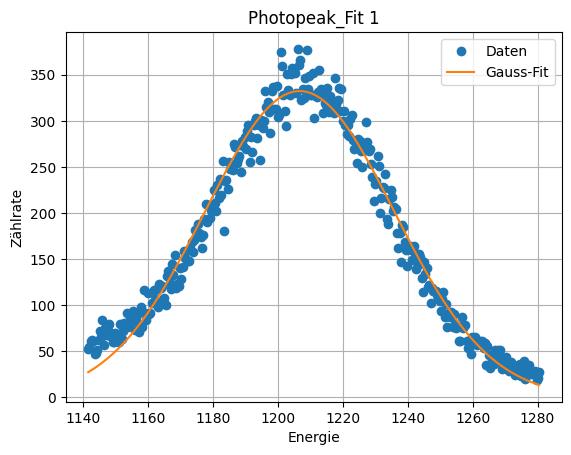

Amplitude: 332.34, Mittelwert: 1206.72, Sigma: 29.15


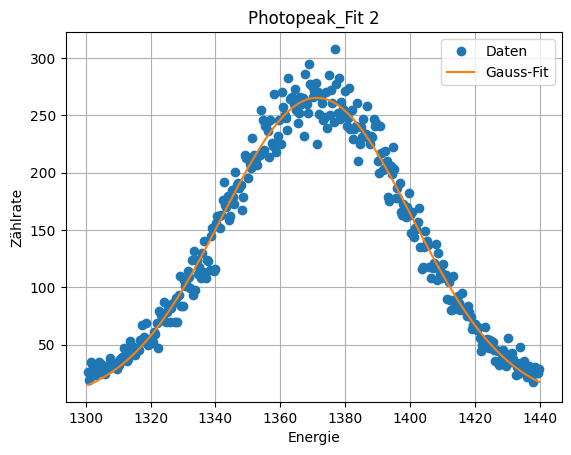

Amplitude: 265.36, Mittelwert: 1371.26, Sigma: 29.32


In [176]:
area = np.array([[2950,3300], [3350,3700]])



def Gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
mu_arr = np.array([])

for i in range(len(area)):

    xdata = Linear(np.arange(len(Co60_NaI_spec)), mg  , cg  )[area[i,0]:area[i,1]]
    ydata = Co60_NaI_spec[area[i,0]:area[i,1]] 
    
    p0 = [np.max(ydata), xdata[np.argmax(ydata)], 2]


    parameters, _ = curve_fit(Gauss, xdata, ydata, p0=p0)


    A_fit, mu_fit, sigma_fit = parameters
    fit_y = Gauss(np.linspace(xdata[0], xdata[-1], 100), A_fit, mu_fit, sigma_fit)
    mu_arr = np.append(mu_arr, mu_fit)


    plt.plot(xdata, ydata, 'o', label='Daten')
    plt.plot(np.linspace(xdata[0], xdata[-1],100), fit_y, '-', label='Gauss-Fit')
    plt.legend()
    plt.xlabel("Energie")
    plt.ylabel("Zählrate")
    plt.title(f'Photopeak_Fit {i+1}')
    plt.grid(True)
    plt.show()
    print(f"Amplitude: {A_fit:.2f}, Mittelwert: {mu_fit:.2f}, Sigma: {sigma_fit:.2f}")
